Problem Statement
   The objective of this project is to develop machine learning classification models to predict the presence of heart disease in a patient based on 
   various clinical and demographic attributes. The Cleveland Heart Disease dataset contains patient-related features such as age, sex, chest pain type,resting blood pressure, cholesterol level, maximum heart rate, and other clinical measurements.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

In [13]:
columns = [
    "age", "sex", "cp", "trestbps", "chol",
    "fbs", "restecg", "thalach", "exang",
    "oldpeak", "slope", "ca", "thal", "num"
]
df = pd.read_csv(
    "processed.cleveland.data",
    names=columns,
    na_values="?"
)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


age: age in years
sex: sex (1 = male; 0 = female)
cp:chest pain type(1=typical angina,2=atypical angina,3=non-anginal pain,4=asymptomatic)
trestbps: resting blood pressure (in mm Hg on admission to the hospital)
chol: serum cholestoral in mg/dl
fbs: (fasting blood sugar > 120 mg/dl)  (1 = true; 0 = false)
restecg: resting electrocardiographic results(0=normal,1=having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV),2=showing probable or definite left ventricular hypertrophy by Estes' criteria)
thalach: maximum heart rate achieved
exang: exercise induced angina (1 = yes; 0 = no)
oldpeak = ST depression induced by exercise relative to rest
slope: the slope of the peak exercise ST segment(1=upsloping,2=flat,3=downsloping)
ca: number of major vessels (0-3) colored by flourosopy
thal: 3 = normal; 6 = fixed defect; 7 = reversable defect
num: (0=no significant heart disease,1-4=increasing levels of disease diagnosis)

In [6]:
print("Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nStatistical Description:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Shape: (303, 14)

Data Types:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
num           int64
dtype: object

Statistical Description:
              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.438944    0.679868    3.158416  131.689769  246.693069    0.148515   
std      9.038662    0.467299    0.960126   17.599748   51.776918    0.356198   
min     29.000000    0.000000    1.000000   94.000000  126.000000    0.000000   
25%     48.000000    0.000000    3.000000  120.000000  211.000000    0.000000   
50%     56.000000    1.000000    3.000000  130.000000  241.000000    0.000000   
75%     61.000000    1.000000    4.000000  140.000000  275.000000    0.000000   
ma

In [7]:
print("Target value counts:")
print(df["num"].value_counts().sort_index())

print("\nTarget percentages:")
print(df["num"].value_counts(normalize=True).sort_index() * 100)

Target value counts:
num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

Target percentages:
num
0    54.125413
1    18.151815
2    11.881188
3    11.551155
4     4.290429
Name: proportion, dtype: float64


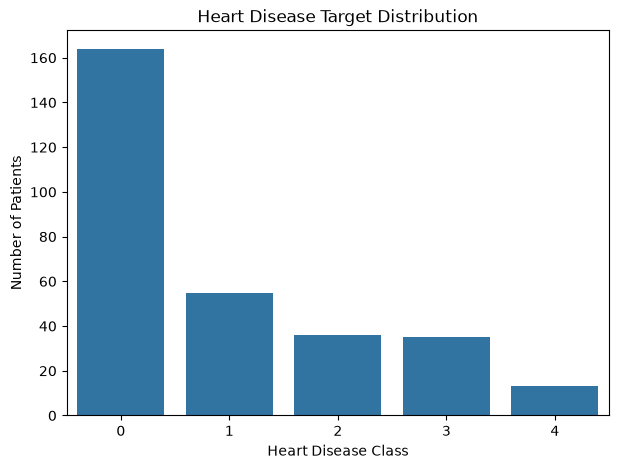

In [8]:
plt.figure(figsize=(7, 5))

sns.countplot(x="num", data=df)

plt.title("Heart Disease Target Distribution")
plt.xlabel("Heart Disease Class")
plt.ylabel("Number of Patients")
plt.show()

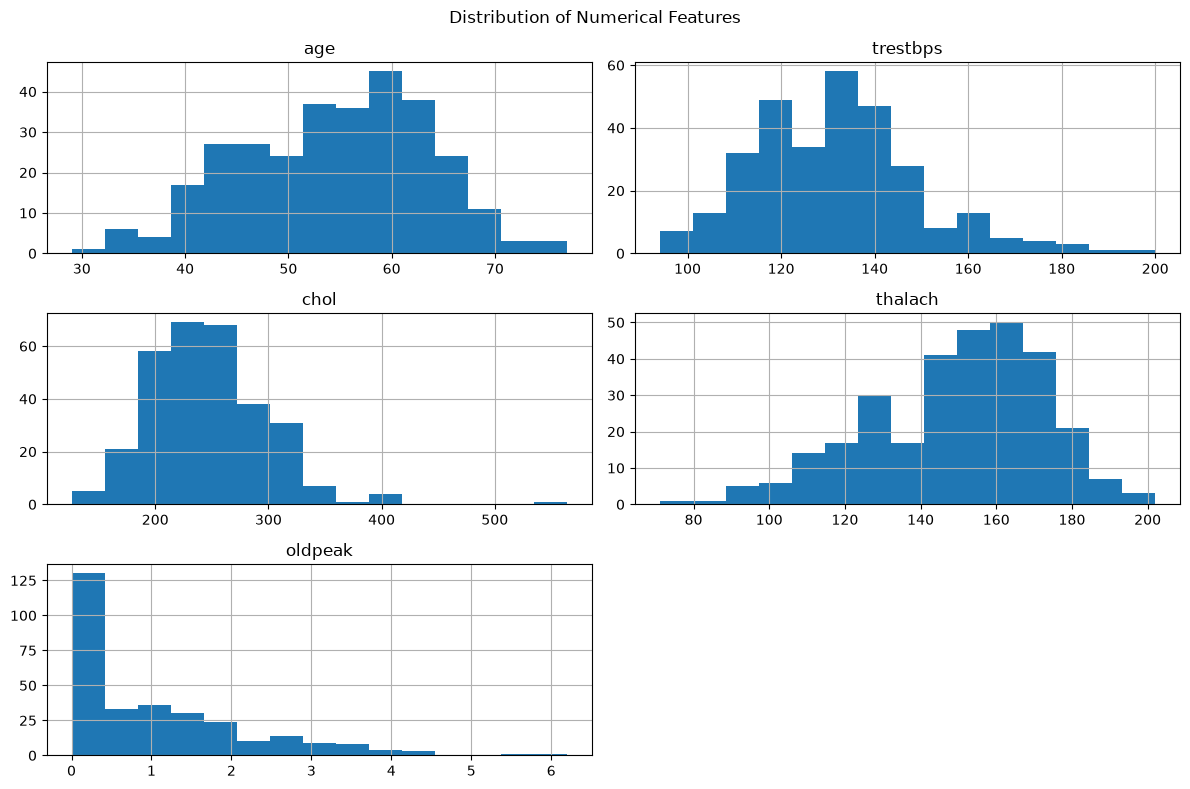

In [12]:
numerical_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]

df[numerical_cols].hist(figsize=(12, 8), bins=15)

plt.suptitle("Distribution of Numerical Features")
plt.tight_layout()
plt.show()

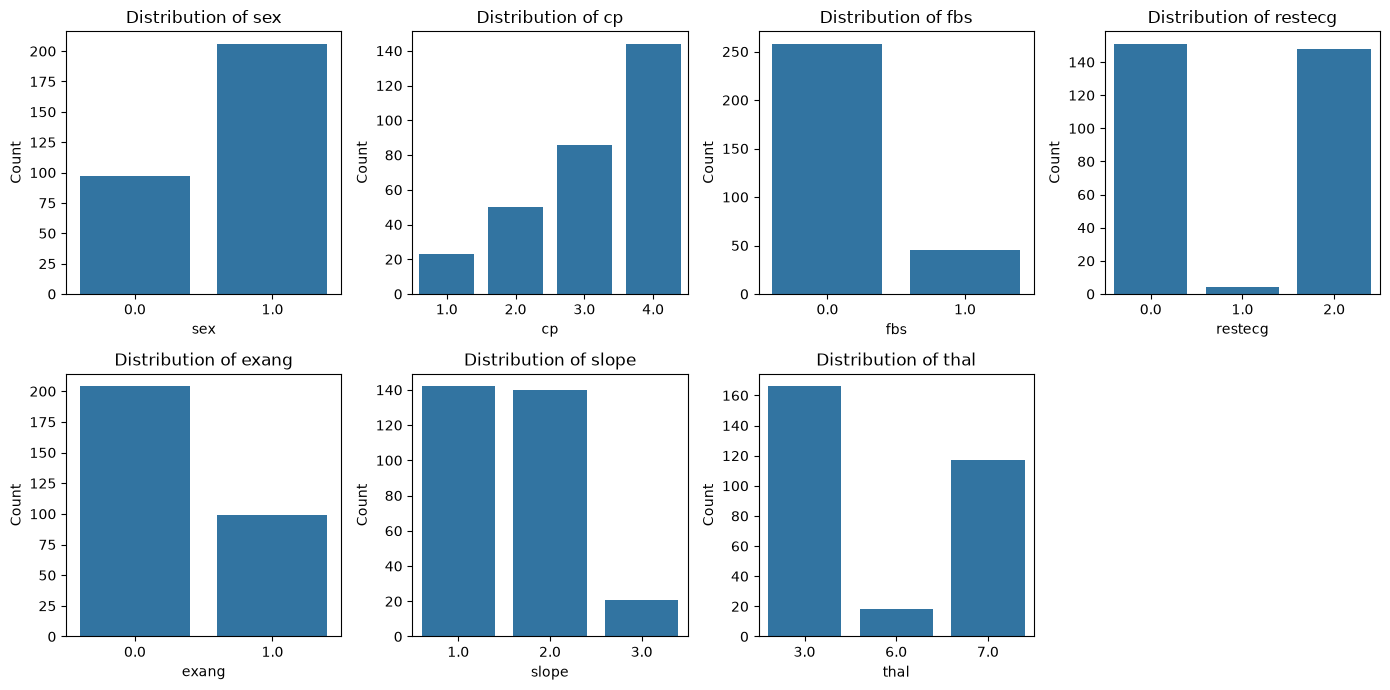

In [15]:
categorical_cols = [
    "sex", "cp", "fbs", "restecg",
    "exang", "slope", "thal"
]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for ax, col in zip(axes.flatten(), categorical_cols):
    sns.countplot(x=col, data=df, ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

# Hide the unused subplot
axes.flatten()[-1].set_visible(False)

plt.tight_layout()
plt.show()

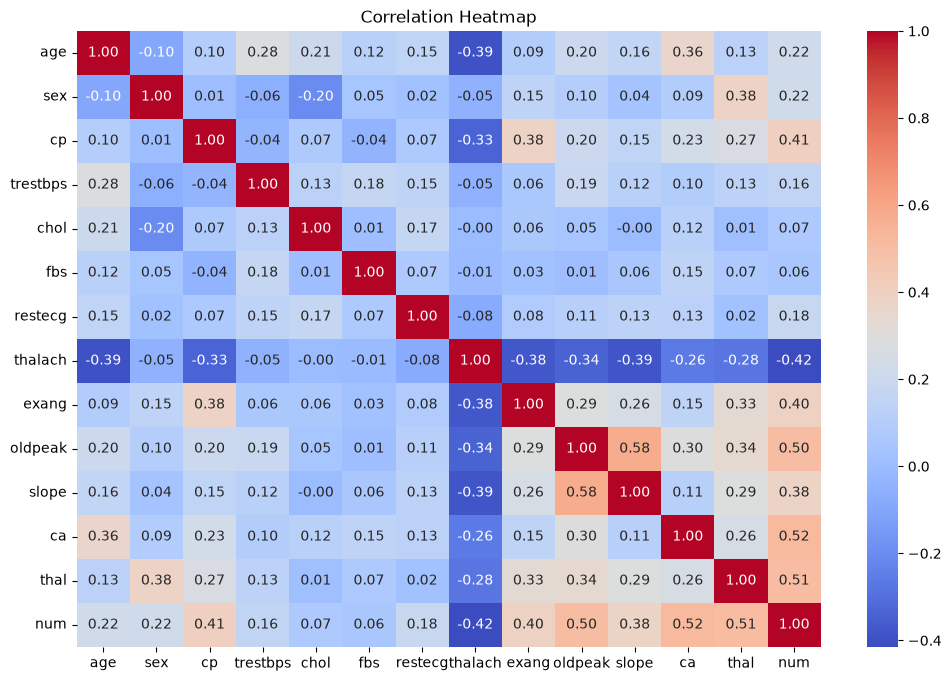

In [16]:
plt.figure(figsize=(12, 8))

correlation = df.corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

From the correlation heatmap, ca, thal, and oldpeak showed relatively stronger positive relationships with the target, while thalach showed a moderate negative relationship.
chol and fbs showed relatively weak linear correlations with the target

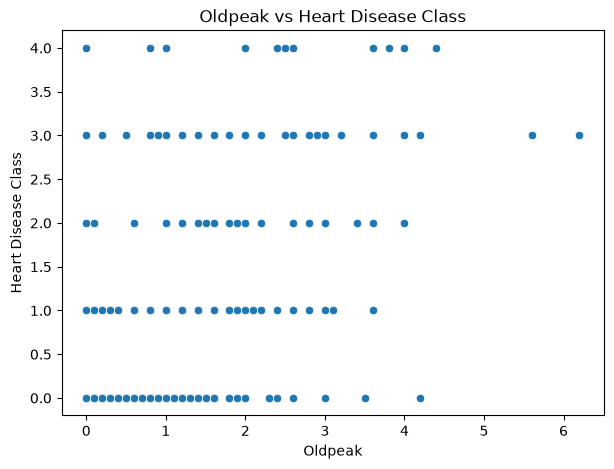

In [17]:
plt.figure(figsize=(7, 5))

sns.scatterplot(data=df, x="oldpeak", y="num")

plt.title("Oldpeak vs Heart Disease Class")
plt.xlabel("Oldpeak")
plt.ylabel("Heart Disease Class")
plt.show()

Higher heart disease classes shows a wider spread and higher values of `oldpeak`. This indicates that `oldpeak` may have a relationship with the severity of heart disease in the dataset.

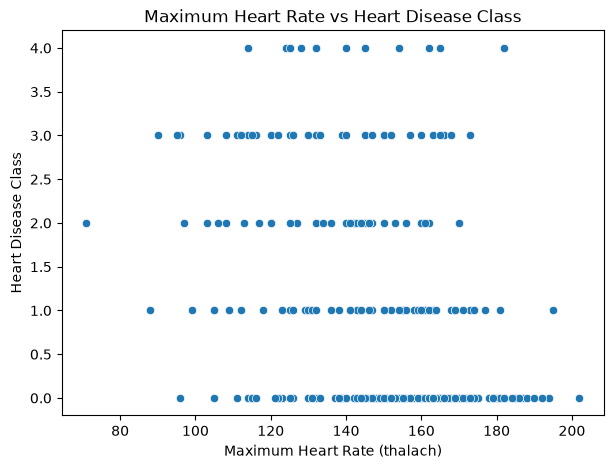

In [18]:
plt.figure(figsize=(7, 5))

sns.scatterplot(data=df, x="thalach", y="num")

plt.title("Maximum Heart Rate vs Heart Disease Class")
plt.xlabel("Maximum Heart Rate (thalach)")
plt.ylabel("Heart Disease Class")
plt.show()

The plot shows a general tendency for `thalach` values to decrease as the heart disease class increases. This agrees with the negative correlation observed between `thalach` and the target variable in the correlation heatmap.

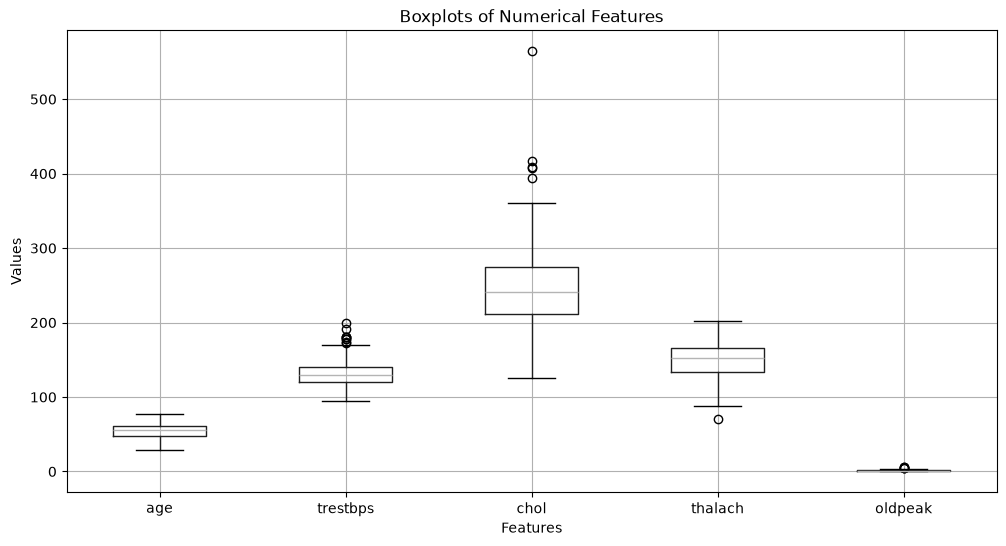

In [19]:
numerical_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]

plt.figure(figsize=(12, 6))

df[numerical_cols].boxplot()

plt.title("Boxplots of Numerical Features")
plt.xlabel("Features")
plt.ylabel("Values")

plt.show()

The boxplot show some potential extreme values in trestbps, chol, thalach, and oldpeak.

In [20]:
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"{col}:")
    print(f"  Lower bound = {lower_bound:.2f}")
    print(f"  Upper bound = {upper_bound:.2f}")
    print(f"  Number of outliers = {len(outliers)}")
    print()

age:
  Lower bound = 28.50
  Upper bound = 80.50
  Number of outliers = 0

trestbps:
  Lower bound = 90.00
  Upper bound = 170.00
  Number of outliers = 9

chol:
  Lower bound = 115.00
  Upper bound = 371.00
  Number of outliers = 5

thalach:
  Lower bound = 84.75
  Upper bound = 214.75
  Number of outliers = 1

oldpeak:
  Lower bound = -2.40
  Upper bound = 4.00
  Number of outliers = 5



In [28]:
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = df[col].clip(
        lower=lower_bound,
        upper=upper_bound
    )

Outliers have been capped using the IQR method

In [26]:
categorical_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "thal"]

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts().sort_index())

print("\nca value counts:")
print(df["ca"].value_counts().sort_index())


sex:
sex
0.0     97
1.0    206
Name: count, dtype: int64

cp:
cp
1.0     23
2.0     50
3.0     86
4.0    144
Name: count, dtype: int64

fbs:
fbs
0.0    258
1.0     45
Name: count, dtype: int64

restecg:
restecg
0.0    151
1.0      4
2.0    148
Name: count, dtype: int64

exang:
exang
0.0    204
1.0     99
Name: count, dtype: int64

slope:
slope
1.0    142
2.0    140
3.0     21
Name: count, dtype: int64

thal:
thal
3.0    168
6.0     18
7.0    117
Name: count, dtype: int64

ca value counts:
ca
0.0    180
1.0     65
2.0     38
3.0     20
Name: count, dtype: int64


The categorical features contain valid category values, and no invalid categorical values were detected.

In [23]:
for col in ["ca", "thal"]:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64


Missing values were found in ca and thal and were handled using mode imputation.

In [27]:
X = df.drop("num", axis=1)
y = df["num"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (303, 13)
y shape: (303,)


In [29]:
numerical_cols = [
    "age", "trestbps", "chol", "thalach", "oldpeak"
]
categorical_cols = [
    "sex", "cp", "fbs", "restecg",
    "exang", "slope", "ca", "thal"
]

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (242, 13)
Testing set: (61, 13)


In [31]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols)
])
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (242, 28)
Processed testing shape: (61, 28)


In [32]:
pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_processed)
X_test_pca = pca.transform(X_test_processed)

print("Before PCA:", X_train_processed.shape)
print("After PCA:", X_train_pca.shape)

Before PCA: (242, 28)
After PCA: (242, 14)


In [33]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)
logistic_model.fit(X_train_pca, y_train)
y_pred_lr = logistic_model.predict(X_test_pca)
accuracy_lr = accuracy_score(y_test, y_pred_lr)

precision_lr = precision_score(
    y_test, y_pred_lr,
    average="weighted",
    zero_division=0
)

recall_lr = recall_score(
    y_test, y_pred_lr,
    average="weighted",
    zero_division=0
)

f1_lr = f1_score(
    y_test, y_pred_lr,
    average="weighted",
    zero_division=0
)

print("Logistic Regression")
print("Accuracy :", accuracy_lr)
print("Precision:", precision_lr)
print("Recall   :", recall_lr)
print("Weighted F1:", f1_lr)

cm_lr = confusion_matrix(y_test, y_pred_lr)

print("Confusion Matrix:")
print(cm_lr)

Logistic Regression
Accuracy : 0.5737704918032787
Precision: 0.5274331708757939
Recall   : 0.5737704918032787
Weighted F1: 0.54839968774395
Confusion Matrix:
[[30  2  1  0  0]
 [ 5  3  3  0  0]
 [ 1  2  0  4  0]
 [ 1  1  2  2  1]
 [ 0  1  0  2  0]]


In [34]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_pca, y_train)

y_pred_knn = knn_model.predict(X_test_pca)

accuracy_knn = accuracy_score(y_test, y_pred_knn)

precision_knn = precision_score(
    y_test, y_pred_knn,
    average="weighted",
    zero_division=0
)

recall_knn = recall_score(
    y_test, y_pred_knn,
    average="weighted",
    zero_division=0
)

f1_knn = f1_score(
    y_test, y_pred_knn,
    average="weighted",
    zero_division=0
)

print("KNN")
print("Accuracy :", accuracy_knn)
print("Precision:", precision_knn)
print("Recall   :", recall_knn)
print("Weighted F1:", f1_knn)

cm_knn = confusion_matrix(y_test, y_pred_knn)

print("Confusion Matrix:")
print(cm_knn)

KNN
Accuracy : 0.6065573770491803
Precision: 0.551459038516847
Recall   : 0.6065573770491803
Weighted F1: 0.5718617717232355
Confusion Matrix:
[[31  1  1  0  0]
 [ 6  4  1  0  0]
 [ 1  3  1  2  0]
 [ 0  4  2  1  0]
 [ 0  1  2  0  0]]


In [35]:
gnb_model = GaussianNB()

gnb_model.fit(X_train_pca, y_train)

y_pred_gnb = gnb_model.predict(X_test_pca)

accuracy_gnb = accuracy_score(y_test, y_pred_gnb)

precision_gnb = precision_score(
    y_test, y_pred_gnb,
    average="weighted",
    zero_division=0
)

recall_gnb = recall_score(
    y_test, y_pred_gnb,
    average="weighted",
    zero_division=0
)

f1_gnb = f1_score(
    y_test, y_pred_gnb,
    average="weighted",
    zero_division=0
)

print("Gaussian Naive Bayes")
print("Accuracy :", accuracy_gnb)
print("Precision:", precision_gnb)
print("Recall   :", recall_gnb)
print("Weighted F1:", f1_gnb)

cm_gnb = confusion_matrix(y_test, y_pred_gnb)

print("Confusion Matrix:")
print(cm_gnb)

Gaussian Naive Bayes
Accuracy : 0.639344262295082
Precision: 0.592271662763466
Recall   : 0.639344262295082
Weighted F1: 0.6133590485374477
Confusion Matrix:
[[31  1  1  0  0]
 [ 3  7  1  0  0]
 [ 1  2  0  4  0]
 [ 0  2  3  1  1]
 [ 0  2  1  0  0]]


In [36]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train_pca, y_train)

y_pred_dt = dt_model.predict(X_test_pca)

accuracy_dt = accuracy_score(y_test, y_pred_dt)

precision_dt = precision_score(
    y_test, y_pred_dt,
    average="weighted",
    zero_division=0
)

recall_dt = recall_score(
    y_test, y_pred_dt,
    average="weighted",
    zero_division=0
)

f1_dt = f1_score(
    y_test, y_pred_dt,
    average="weighted",
    zero_division=0
)

print("Decision Tree")
print("Accuracy :", accuracy_dt)
print("Precision:", precision_dt)
print("Recall   :", recall_dt)
print("Weighted F1:", f1_dt)

cm_dt = confusion_matrix(y_test, y_pred_dt)

print("Confusion Matrix:")
print(cm_dt)

Decision Tree
Accuracy : 0.5737704918032787
Precision: 0.565714789353076
Recall   : 0.5737704918032787
Weighted F1: 0.5663132371485795
Confusion Matrix:
[[27  2  2  0  2]
 [ 4  5  0  2  0]
 [ 0  2  0  5  0]
 [ 0  3  1  3  0]
 [ 0  3  0  0  0]]


In [38]:
svc_model = SVC(
    probability=True,
    random_state=42
)

svc_model.fit(X_train_pca, y_train)

y_pred_svc = svc_model.predict(X_test_pca)

accuracy_svc = accuracy_score(y_test, y_pred_svc)

precision_svc = precision_score(
    y_test, y_pred_svc,
    average="weighted",
    zero_division=0
)

recall_svc = recall_score(
    y_test, y_pred_svc,
    average="weighted",
    zero_division=0
)

f1_svc = f1_score(
    y_test, y_pred_svc,
    average="weighted",
    zero_division=0
)

print("SVC")
print("Accuracy :", accuracy_svc)
print("Precision:", precision_svc)
print("Recall   :", recall_svc)
print("Weighted F1:", f1_svc)

cm_svc = confusion_matrix(y_test, y_pred_svc)

print("Confusion Matrix:")
print(cm_svc)

SVC
Accuracy : 0.5573770491803278
Precision: 0.42950819672131146
Recall   : 0.5573770491803278
Weighted F1: 0.48399687743950043
Confusion Matrix:
[[32  0  1  0  0]
 [ 8  2  1  0  0]
 [ 2  2  0  3  0]
 [ 2  3  2  0  0]
 [ 0  3  0  0  0]]


C:\Users\sweth\AppData\Roaming\Python\Python314\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [40]:
y_prob_lr = logistic_model.predict_proba(X_test_pca)
y_prob_knn = knn_model.predict_proba(X_test_pca)
y_prob_gnb = gnb_model.predict_proba(X_test_pca)
y_prob_dt = dt_model.predict_proba(X_test_pca)
y_prob_svc = svc_model.predict_proba(X_test_pca)
roc_lr = roc_auc_score(
    y_test, y_prob_lr,
    multi_class="ovr",
    average="weighted"
)

roc_knn = roc_auc_score(
    y_test, y_prob_knn,
    multi_class="ovr",
    average="weighted"
)

roc_gnb = roc_auc_score(
    y_test, y_prob_gnb,
    multi_class="ovr",
    average="weighted"
)

roc_dt = roc_auc_score(
    y_test, y_prob_dt,
    multi_class="ovr",
    average="weighted"
)

roc_svc = roc_auc_score(
    y_test, y_prob_svc,
    multi_class="ovr",
    average="weighted"
)
print("ROC-AUC Scores")
print("Logistic Regression:", roc_lr)
print("KNN:", roc_knn)
print("Gaussian Naive Bayes:", roc_gnb)
print("Decision Tree:", roc_dt)
print("SVC:", roc_svc)

ROC-AUC Scores
Logistic Regression: 0.8655048887213952
KNN: 0.7987618927980714
Gaussian Naive Bayes: 0.8790663723563668
Decision Tree: 0.7187374566684913
SVC: 0.8461551529725639


ROC-AUC was calculated using the One-vs-Rest (OvR) approach because the dataset contains five target classes

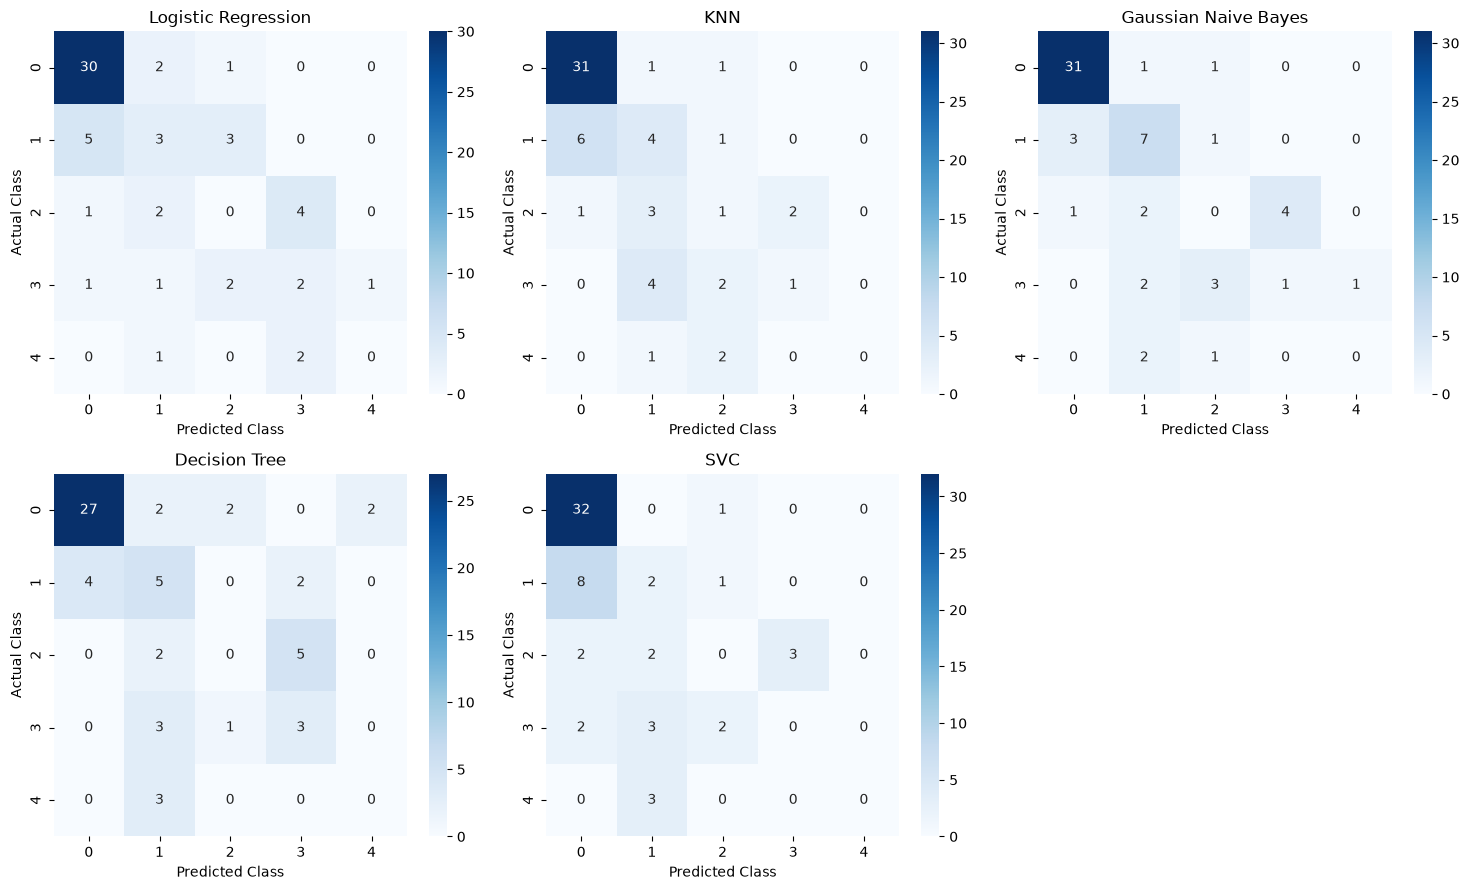

In [41]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

models_cm = [
    ("Logistic Regression", cm_lr),
    ("KNN", cm_knn),
    ("Gaussian Naive Bayes", cm_gnb),
    ("Decision Tree", cm_dt),
    ("SVC", cm_svc)
]

for ax, (name, cm) in zip(axes.flatten(), models_cm):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax
    )
    
    ax.set_title(name)
    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("Actual Class")

# Hide the unused sixth plot
axes.flatten()[-1].set_visible(False)

plt.tight_layout()
plt.show()

In [42]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Gaussian Naive Bayes",
        "Decision Tree",
        "SVC"
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_knn,
        accuracy_gnb,
        accuracy_dt,
        accuracy_svc
    ],
    "Precision": [
        precision_lr,
        precision_knn,
        precision_gnb,
        precision_dt,
        precision_svc
    ],
    "Recall": [
        recall_lr,
        recall_knn,
        recall_gnb,
        recall_dt,
        recall_svc
    ],
    "Weighted F1": [
        f1_lr,
        f1_knn,
        f1_gnb,
        f1_dt,
        f1_svc
    ],
    "ROC-AUC": [
        roc_lr,
        roc_knn,
        roc_gnb,
        roc_dt,
        roc_svc
    ]
})

comparison.round(3)

,Model,Accuracy,Precision,Recall,Weighted F1,ROC-AUC
0,Logistic Regression,0.574,0.527,0.574,0.548,0.866
1,KNN,0.607,0.551,0.607,0.572,0.799
2,Gaussian Naive Bayes,0.639,0.592,0.639,0.613,0.879
3,Decision Tree,0.574,0.566,0.574,0.566,0.719
4,SVC,0.557,0.430,0.557,0.484,0.846


Gaussian Naive Bayes achieved the highest Accuracy, Weighted F1, Recall, and ROC-AUC among the five Part-A classifiers on the test set.